# MVP v0.3: Multi-Target-Policy OPE Evaluation

**Date:** 2026-03-10  
**Builds on:** MVP v0.1 (pipeline) + v0.2 (guidance)

**Goal:** Test whether SOPE can **rank** multiple target policies of varying quality.

**Key design: Data partition for fairness**
- **Demos 0-149 (150):** Train the diffusion model (behavior data) — the OPE "world model"
- **Demos 150-199 (50):** Train BC_Gaussian target policies on subsets of these held-out demos

This ensures target policies are trained on data the diffusion model has **never seen**,
so guidance genuinely steers toward different distributions.

**Pipeline:**
1. Load & partition 200 demos → behavior (150) + target (50)
2. Train chunk diffusion on behavior data (10 epochs)
3. Train 5 BC_Gaussian policies on {50, 40, 30, 20, 10} of the held-out target demos
4. Collect oracle rollouts for each (20 per policy)
5. Run guided SOPE for each target policy
6. Evaluate: Spearman ρ, Regret@1

**Each BC_Gaussian IS the target policy AND its own guidance proxy — zero proxy error.**

In [1]:
import sys, os
import numpy as np
import torch
import torch.nn as nn
import h5py
import json
import matplotlib.pyplot as plt
from pathlib import Path
from copy import deepcopy
from tqdm import tqdm

# Project root
PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

# SOPE imports
from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning

# Robomimic imports
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_env_from_checkpoint
)

# Multi-policy metrics
from latent_sope.eval.metrics import multi_policy_ope_eval

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
CKPT_DIR = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models/test/20260309132349"
DIFFUSION_CKPT_DIR = PROJECT_ROOT / "diffusion_ckpts/mvp_sope"

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
logit_scale                                                    | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


## Configuration

In [2]:
# ── Obs/action dimension config (same as v0.1/v0.2) ──
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
STATE_KEEP_INDICES = [0, 1, 2, 7, 8, 9, 10, 11, 12, 17, 18]  # 11 dims (no quaternions)
ACTION_KEEP_INDICES = [0, 1, 2, 6]  # 4 dims (position + gripper, no orientation)

STATE_DIM = len(STATE_KEEP_INDICES)   # 11
ACTION_DIM = len(ACTION_KEEP_INDICES) # 4
TRANSITION_DIM = STATE_DIM + ACTION_DIM  # 15

# ── Data partition ──
N_BEHAVIOR_DEMOS = 150  # demos 0-149 → diffusion model training
N_TARGET_DEMOS = 50     # demos 150-199 → BC_Gaussian target policies

# ── Diffusion config ──
CHUNK_SIZE = 4
N_DIFFUSION_STEPS = 256
DIM_MULTS = (1, 4, 8)
BASE_DIM = 32
ACTION_WEIGHT = 5.0
PREDICT_EPSILON = False

# Diffusion training
DIFF_TRAIN_EPOCHS = 10
DIFF_TRAIN_STEPS_PER_EPOCH = 1000
DIFF_BATCH_SIZE = 128
DIFF_LR = 3e-4
STRIDE = 1

# ── Multi-policy config ──
# Each BC is trained on a different number of the 50 held-out target demos
TARGET_DEMO_COUNTS = [50, 40, 30, 20, 10]
POLICY_NAMES = [f"bc_{n}demos" for n in TARGET_DEMO_COUNTS]

# BC_Gaussian training
BC_HIDDEN_DIM = 64
BC_TRAIN_EPOCHS = 500
BC_LR = 1e-3
BC_BATCH_SIZE = 256

# Oracle rollouts per policy
N_ORACLE_ROLLOUTS = 20
HORIZON = 60

# OPE config
GUIDANCE_SCALE = 0.1  # best scale from v0.2
NUM_SYNTHETIC_TRAJS = 50
T_GEN = 60
GAMMA = 1.0
NORMALIZE_GRAD = True

# Reward
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84

print(f"Data partition: {N_BEHAVIOR_DEMOS} behavior demos, {N_TARGET_DEMOS} target demos")
print(f"Policies: {POLICY_NAMES}")
print(f"Diffusion training: {DIFF_TRAIN_EPOCHS} epochs x {DIFF_TRAIN_STEPS_PER_EPOCH} steps")
print(f"BC training: {BC_TRAIN_EPOCHS} epochs, hidden_dim={BC_HIDDEN_DIM}")
print(f"Oracle: {N_ORACLE_ROLLOUTS} rollouts per policy")
print(f"OPE: {NUM_SYNTHETIC_TRAJS} synthetic trajs, guidance_scale={GUIDANCE_SCALE}")

Data partition: 150 behavior demos, 50 target demos
Policies: ['bc_50demos', 'bc_40demos', 'bc_30demos', 'bc_20demos', 'bc_10demos']
Diffusion training: 10 epochs x 1000 steps
BC training: 500 epochs, hidden_dim=64
Oracle: 20 rollouts per policy
OPE: 50 synthetic trajs, guidance_scale=0.1


## Step 1: Load & Partition Demo Data

Load 200 human demos, split into:
- **Behavior data** (demos 0-149): used to train the diffusion model
- **Target data** (demos 150-199): used to train BC_Gaussian target policies

Normalization stats are computed over the **behavior data only** (what the diffusion model sees).

In [3]:
def load_robomimic_demos(hdf5_path, obs_keys, state_keep_idx, action_keep_idx):
    """Load robomimic demos from HDF5 → list of {states, actions} dicts."""
    data = []
    all_states_list = []
    all_actions_list = []

    with h5py.File(hdf5_path, "r") as f:
        demo_keys = sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1]))
        print(f"Found {len(demo_keys)} demos")

        for dk in tqdm(demo_keys, desc="Loading demos"):
            demo = f["data"][dk]
            obs_arrays = [demo["obs"][k][:] for k in obs_keys]
            full_state = np.concatenate(obs_arrays, axis=-1)
            state = full_state[:, state_keep_idx].astype(np.float32)
            full_actions = demo["actions"][:].astype(np.float32)
            actions = full_actions[:, action_keep_idx]
            rewards = demo["rewards"][:].astype(np.float32)

            episode = {
                "states": state[:-1],
                "actions": actions[:-1],
                "rewards": rewards[:-1],
                "next-states": state[1:],
            }
            data.append(episode)
            all_states_list.append(state)
            all_actions_list.append(actions)

    all_states = np.concatenate(all_states_list, axis=0)
    all_actions = np.concatenate(all_actions_list, axis=0)
    total_transitions = sum(len(ep["states"]) for ep in data)
    print(f"Loaded {len(data)} episodes, {total_transitions} total transitions")
    return data, all_states, all_actions

all_data, all_states, all_actions = load_robomimic_demos(
    DEMO_HDF5, OBS_KEYS, STATE_KEEP_INDICES, ACTION_KEEP_INDICES
)

# ── Partition ──
behavior_data = all_data[:N_BEHAVIOR_DEMOS]
target_data = all_data[N_BEHAVIOR_DEMOS:]
print(f"\nPartition:")
print(f"  Behavior: {len(behavior_data)} demos ({sum(len(ep['states']) for ep in behavior_data)} transitions)")
print(f"  Target:   {len(target_data)} demos ({sum(len(ep['states']) for ep in target_data)} transitions)")

# Normalization stats from BEHAVIOR data only
behavior_states = np.concatenate([ep["states"] for ep in behavior_data], axis=0)
behavior_actions = np.concatenate([ep["actions"] for ep in behavior_data], axis=0)
# Include the last state of each episode for complete normalization
behavior_states_full = np.concatenate(
    [np.concatenate([ep["states"], ep["next-states"][-1:]], axis=0) for ep in behavior_data], axis=0
)

mean_state = np.mean(behavior_states_full, axis=0)
std_state = np.std(behavior_states_full, axis=0)
mean_action = np.mean(behavior_actions, axis=0)
std_action = np.std(behavior_actions, axis=0)
norm_mean = np.concatenate([mean_state, mean_action]).astype(np.float32)
norm_std = np.maximum(np.concatenate([std_state, std_action]).astype(np.float32), 1e-6)
norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

print(f"\nNormalization stats (from behavior data only):")
print(f"  mean shape: {norm_mean.shape}, std shape: {norm_std.shape}")

Found 200 demos


Loading demos:   0%|          | 0/200 [00:00<?, ?it/s]

Loading demos:  23%|██▎       | 46/200 [00:00<00:00, 459.40it/s]

Loading demos:  46%|████▌     | 92/200 [00:00<00:00, 445.55it/s]

Loading demos:  69%|██████▉   | 138/200 [00:00<00:00, 450.30it/s]

Loading demos:  92%|█████████▏| 184/200 [00:00<00:00, 439.56it/s]

Loading demos: 100%|██████████| 200/200 [00:00<00:00, 452.69it/s]

Loaded 200 episodes, 9466 total transitions

Partition:
  Behavior: 150 demos (7104 transitions)
  Target:   50 demos (2362 transitions)



Normalization stats (from behavior data only):
  mean shape: (15,), std shape: (15,)


## Step 2: Load Chunk Diffusion Model

Load pre-trained diffusion model from `diffusion_ckpts/mvp_v03_diffusion/`.
This was trained on the 150 behavior demos in a previous run.

In [4]:
from torch.utils.data import Dataset, DataLoader

DIFF_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v03_diffusion"

# ── Build diffusion model architecture ──
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE,
    transition_dim=TRANSITION_DIM,
    dim=BASE_DIM,
    dim_mults=DIM_MULTS,
    attention=False,
).to(device)

diffusion_model = GaussianDiffusion(
    model=temporal_model,
    horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM,
    action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn,
    unnormalizer=unnormalize_fn,
    predict_epsilon=PREDICT_EPSILON,
    loss_type="l2",
    clip_denoised=False,
    action_weight=ACTION_WEIGHT,
    loss_weights=None,
    loss_discount=1.0,
).to(device)

# Load pre-trained EMA weights
ema_weights = torch.load(DIFF_SAVE_DIR / "diffusion_model_ema.pt", map_location=device)
diffusion_model.load_state_dict(ema_weights)
diffusion_model.eval()

n_params = sum(p.numel() for p in diffusion_model.parameters())
print(f"Loaded diffusion model from {DIFF_SAVE_DIR}: {n_params:,} parameters")

# Placeholder for summary cell (no training loss history when loading)
loss_history = [float("nan")]

[ models/temporal ] Channel dimensions: [(15, 32), (32, 128), (128, 256)]
[(15, 32), (32, 128), (128, 256)]


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


Loaded diffusion model from /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v03_diffusion: 3,684,143 parameters


## Step 3: Load Pre-Trained BC_Gaussian Target Policies

Load 5 BC_Gaussian policies from `diffusion_ckpts/mvp_v03_bc_policies/`.
These were trained on different amounts of the **held-out target demos** (150-199).

In [5]:
class BCGaussian(nn.Module):
    """BC policy with Gaussian action distribution."""

    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )
        self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, state):
        mean = self.net(state)
        std = torch.exp(self.log_std)
        return mean, std

    def sample_action(self, state):
        mean, std = self.forward(state)
        return mean + std * torch.randn_like(mean)

    def log_prob_extended(self, state, action):
        mean, std = self.forward(state)
        log_prob = -0.5 * ((action - mean) / std) ** 2 - self.log_std - 0.5 * np.log(2 * np.pi)
        return log_prob.sum(dim=-1)


# ── Load pre-trained BC_Gaussians from saved checkpoints ──
BC_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v03_bc_policies"
policies = {}

for n_demos, name in zip(TARGET_DEMO_COUNTS, POLICY_NAMES):
    ckpt_path = BC_SAVE_DIR / f"{name}.pt"
    ckpt_data = torch.load(ckpt_path, map_location=device)

    policy = BCGaussian(
        ckpt_data["state_dim"],
        ckpt_data["action_dim"],
        ckpt_data["hidden_dim"],
    ).to(device)
    policy.load_state_dict(ckpt_data["state_dict"])
    policy.eval()
    policies[name] = policy

    print(f"Loaded {name}: {ckpt_data['n_transitions']} transitions, "
          f"trained {ckpt_data['train_epochs']} epochs")

print(f"\nLoaded {len(policies)} policies from {BC_SAVE_DIR}")

Loaded bc_50demos: 2362 transitions, trained 500 epochs
Loaded bc_40demos: 1885 transitions, trained 500 epochs
Loaded bc_30demos: 1441 transitions, trained 500 epochs
Loaded bc_20demos: 945 transitions, trained 500 epochs
Loaded bc_10demos: 500 transitions, trained 500 epochs

Loaded 5 policies from /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v03_bc_policies


## Step 4: Oracle Rollouts for Each Policy

Roll out each BC_Gaussian in the Lift environment to get ground-truth V^π.
BC_Gaussian outputs 4-dim actions (pos + gripper); we pad orientation dims with zeros.

In [6]:
def obs_dict_to_reduced_state(obs, obs_keys, state_keep_idx):
    """Convert robomimic obs dict → reduced 11-dim state vector."""
    full = np.concatenate([obs[k].flatten() for k in obs_keys])
    return full[state_keep_idx].astype(np.float32)


def reduced_action_to_full(action_4d):
    """Convert 4-dim reduced action → 7-dim full action.
    
    Reduced: [pos_x, pos_y, pos_z, gripper] (indices 0,1,2,6)
    Full: [pos_x, pos_y, pos_z, ori_x, ori_y, ori_z, gripper]
    Orientation deltas set to 0 (no rotation change).
    """
    full = np.zeros(7, dtype=np.float32)
    full[0] = action_4d[0]
    full[1] = action_4d[1]
    full[2] = action_4d[2]
    full[6] = action_4d[3]
    return full


def bc_oracle_rollouts(policy, env, obs_keys, state_keep_idx, n_rollouts, horizon, device):
    """Roll out a BCGaussian policy in the environment.
    
    Returns per-rollout returns scored with ground-truth Lift reward (cube_z > 0.84).
    """
    returns = np.zeros(n_rollouts)

    for i in range(n_rollouts):
        obs = env.reset()
        episode_return = 0.0

        for t in range(horizon):
            state = obs_dict_to_reduced_state(obs, obs_keys, state_keep_idx)
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

            with torch.no_grad():
                action_4d = policy.sample_action(state_t).cpu().numpy()[0]

            action_7d = reduced_action_to_full(action_4d)
            obs, reward, done, info = env.step(action_7d)

            # Ground-truth reward: cube_z > 0.84
            cube_z = obs_dict_to_reduced_state(obs, obs_keys, state_keep_idx)[CUBE_Z_INDEX]
            step_reward = 1.0 if cube_z > LIFT_THRESHOLD else 0.0
            episode_return += step_reward

            if done:
                break

        returns[i] = episode_return

        if (i + 1) % max(1, n_rollouts // 5) == 0:
            print(f"    rollout [{i+1}/{n_rollouts}] running mean={returns[:i+1].mean():.2f}")

    return returns

print("Oracle rollout functions defined.")

Oracle rollout functions defined.


In [7]:
# Build environment from existing checkpoint (reuses robomimic env config)
import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.file_utils as FileUtils

ckpt = load_checkpoint(str(CKPT_DIR), ckpt_path="last.pth")

# Initialize obs utils (normally done inside build_rollout_policy, but we only need the env)
algo_name = ckpt.ckpt_dict.get("algo_name", ckpt.algo_name)
config, _ = FileUtils.config_from_checkpoint(algo_name=algo_name, ckpt_dict=ckpt.ckpt_dict)
ObsUtils.initialize_obs_utils_with_config(config)

env = build_env_from_checkpoint(ckpt, render=False, render_offscreen=False, verbose=True)

# Collect oracle rollouts for each policy
oracle_results = {}

for name in POLICY_NAMES:
    print(f"\n{'='*60}")
    print(f"Oracle rollouts for {name}")
    print(f"{'='*60}")

    returns = bc_oracle_rollouts(
        policies[name], env, OBS_KEYS, STATE_KEEP_INDICES,
        N_ORACLE_ROLLOUTS, HORIZON, device,
    )

    oracle_results[name] = {
        "returns": returns,
        "mean": float(returns.mean()),
        "std": float(returns.std()),
        "success_rate": float((returns > 0).mean()),
    }

    print(f"  V^π = {returns.mean():.3f} ± {returns.std():.3f}, "
          f"success = {(returns > 0).mean()*100:.1f}%")

# Summary table
print(f"\n{'='*60}")
print(f"{'Policy':<15} {'V^π':>8} {'Std':>8} {'Success':>8}")
print(f"{'-'*41}")
for name in POLICY_NAMES:
    r = oracle_results[name]
    print(f"{name:<15} {r['mean']:>8.3f} {r['std']:>8.3f} {r['success_rate']*100:>7.1f}%")

[robosuite WARNING] No private macro file found! (macros.py:57)


[robosuite WARNING] It is recommended to use a private macro file (macros.py:58)


[robosuite WARNING] To setup, run: python /home1/reishuen/miniconda3/envs/latent_sope/lib/python3.10/site-packages/robosuite/scripts/setup_macros.py (macros.py:59)



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'robot0_eef_quat', 'robot0_eef_pos', 'object']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)


...

    rollout [4/20] running mean=0.00


    rollout [8/20] running mean=0.00


    rollout [12/20] running mean=0.00


    rollout [16/20] running mean=0.00


    rollout [20/20] running mean=0.00
  V^π = 0.000 ± 0.000, success = 0.0%

Policy               V^π      Std  Success
-----------------------------------------
bc_50demos         0.000    0.000     0.0%
bc_40demos         0.000    0.000     0.0%
bc_30demos         0.000    0.000     0.0%
bc_20demos         0.000    0.000     0.0%
bc_10demos         0.000    0.000     0.0%


In [8]:
# ── Save oracle rollouts for future reuse ──
ORACLE_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v03_oracle_rollouts"
ORACLE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

oracle_save_data = {}
for name in POLICY_NAMES:
    oracle_save_data[name] = oracle_results[name]["returns"]

np.savez(
    ORACLE_SAVE_DIR / "oracle_results.npz",
    **oracle_save_data,
    policy_names=POLICY_NAMES,
    n_rollouts=N_ORACLE_ROLLOUTS,
    horizon=HORIZON,
)

# Also save a JSON summary for easy inspection
import json
oracle_summary = {
    name: {k: v for k, v in oracle_results[name].items() if k != "returns"}
    for name in POLICY_NAMES
}
with open(ORACLE_SAVE_DIR / "oracle_summary.json", "w") as f:
    json.dump(oracle_summary, f, indent=2)

print(f"Oracle rollouts saved to {ORACLE_SAVE_DIR}")
for name in POLICY_NAMES:
    r = oracle_results[name]
    print(f"  {name}: V^π={r['mean']:.3f}, success={r['success_rate']*100:.1f}%")

Oracle rollouts saved to /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v03_oracle_rollouts
  bc_50demos: V^π=0.000, success=0.0%
  bc_40demos: V^π=0.000, success=0.0%
  bc_30demos: V^π=0.000, success=0.0%
  bc_20demos: V^π=0.000, success=0.0%
  bc_10demos: V^π=0.000, success=0.0%


## Step 5: Guided Trajectory Generation

Generate synthetic trajectories for each target policy using SOPE-style guidance.
Initial states are sampled from the **behavior data** (what the diffusion model was trained on).

In [9]:
def get_initial_states_from_data(offline_data, num_samples, device):
    """Sample initial states from demo dataset."""
    all_initial = np.array([ep["states"][0] for ep in offline_data])
    indices = np.random.choice(len(all_initial), num_samples, replace=True)
    return torch.tensor(all_initial[indices], dtype=torch.float32, device=device)


def generate_guided_trajectories(
    diffusion_model, policy, initial_states,
    normalize_fn, unnormalize_fn,
    state_dim, action_dim, chunk_size, t_gen,
    action_scale, normalize_grad, device,
):
    """Generate full trajectories via guided autoregressive stitching.
    
    At each denoising step:
    1. Get model prediction (mean + variance)
    2. Unnormalize mean to real space
    3. Compute grad_a log pi(a|s) via autograd on BCGaussian
    4. Normalize gradient (unit norm per-timestep)
    5. Add action_scale * gradient to action dims of the mean
    6. Re-normalize and re-apply conditioning
    """
    batch_size = initial_states.shape[0]
    transition_dim = state_dim + action_dim

    # Normalize initial states for conditioning
    padded = torch.cat([
        initial_states,
        torch.zeros(batch_size, action_dim, device=device)
    ], dim=1)
    normalized_initial = normalize_fn(padded)[:, :state_dim]

    all_trajectories = torch.zeros(batch_size, t_gen, transition_dim, device=device)
    conditions = {0: normalized_initial}
    total_generated = 0

    while total_generated < t_gen:
        steps_remaining = t_gen - total_generated
        shape = (batch_size, chunk_size, transition_dim)

        # Start from noise
        x = torch.randn(shape, device=device)
        x = apply_conditioning(x, conditions, state_dim)

        for t_diff in reversed(range(diffusion_model.n_timesteps)):
            t_tensor = torch.full((batch_size,), t_diff, device=device, dtype=torch.long)
            model_mean, _, model_log_variance = diffusion_model.p_mean_variance(x=x, t=t_tensor)
            model_std = torch.exp(0.5 * model_log_variance)

            # ── Guidance step ──
            if action_scale > 0 and policy is not None:
                # Unnormalize to real space
                mean_unnorm = unnormalize_fn(model_mean)

                # Extract states and actions, enable grad on actions
                states_flat = mean_unnorm[:, :, :state_dim].reshape(-1, state_dim).detach()
                actions_flat = mean_unnorm[:, :, state_dim:].reshape(-1, action_dim).detach().requires_grad_(True)

                # Compute log pi(a|s) and gradient
                log_prob = policy.log_prob_extended(states_flat, actions_flat)
                total_log_prob = log_prob.sum()
                grad_action = torch.autograd.grad(total_log_prob, actions_flat)[0]

                # Normalize gradient to unit norm per-timestep
                if normalize_grad:
                    grad_norm = grad_action.norm(dim=-1, keepdim=True) + 1e-6
                    grad_action = grad_action / grad_norm

                # Build guide: zero for states, grad for actions
                guide = torch.zeros_like(mean_unnorm)
                guide[:, :, state_dim:] = grad_action.reshape(batch_size, chunk_size, action_dim)

                # Apply guidance in real space, then re-normalize
                mean_unnorm = mean_unnorm + action_scale * guide
                model_mean = normalize_fn(mean_unnorm)
                model_mean = apply_conditioning(model_mean, conditions, state_dim)

            # Sample
            noise = torch.randn_like(x)
            nonzero_mask = float(t_diff != 0)
            x = model_mean + nonzero_mask * model_std * noise
            x = apply_conditioning(x, conditions, state_dim)

        # Unnormalize generated chunk
        chunk_unnorm = unnormalize_fn(x)

        # Store (1-step overlap: store T-1 steps)
        steps_to_store = min(chunk_size - 1, steps_remaining)
        all_trajectories[:, total_generated:total_generated + steps_to_store] = chunk_unnorm[:, :steps_to_store]
        total_generated += steps_to_store

        if total_generated >= t_gen:
            break

        # Condition next chunk on last state (stay in normalized space)
        conditions = {0: x[:, -1, :state_dim]}

    return all_trajectories.detach().cpu().numpy()


def score_trajectories_gt(trajectories, cube_z_index, threshold, gamma=1.0):
    """Score with ground-truth Lift reward: cube_z > threshold → 1.0 per step."""
    B, T, D = trajectories.shape
    returns = np.zeros(B)
    for i in range(B):
        gamma_t = 1.0
        for t in range(T):
            if trajectories[i, t, cube_z_index] > threshold:
                returns[i] += gamma_t
            gamma_t *= gamma
    return returns

print("Guided generation and scoring functions defined.")

Guided generation and scoring functions defined.


## Step 6: Run Guided SOPE for Each Target Policy

For each BC_Gaussian, generate 50 guided synthetic trajectories and score them.

In [10]:
ope_results = {}

# Use same initial states for all policies (fair comparison)
# Sample from BEHAVIOR data (what the diffusion model knows)
torch.manual_seed(123)
initial_states = get_initial_states_from_data(behavior_data, NUM_SYNTHETIC_TRAJS, device)

for name in POLICY_NAMES:
    print(f"\n{'='*60}")
    print(f"Guided SOPE for {name} (scale={GUIDANCE_SCALE})")
    print(f"{'='*60}")

    synthetic_trajs = generate_guided_trajectories(
        diffusion_model=diffusion_model,
        policy=policies[name],
        initial_states=initial_states,
        normalize_fn=normalize_fn,
        unnormalize_fn=unnormalize_fn,
        state_dim=STATE_DIM,
        action_dim=ACTION_DIM,
        chunk_size=CHUNK_SIZE,
        t_gen=T_GEN,
        action_scale=GUIDANCE_SCALE,
        normalize_grad=NORMALIZE_GRAD,
        device=device,
    )

    # Score
    returns = score_trajectories_gt(synthetic_trajs, CUBE_Z_INDEX, LIFT_THRESHOLD, GAMMA)

    ope_results[name] = {
        "returns": returns,
        "trajectories": synthetic_trajs,
        "estimate": float(returns.mean()),
        "std": float(returns.std()),
        "success_rate": float((returns > 0).mean()),
    }

    oracle_v = oracle_results[name]["mean"]
    ope_v = returns.mean()
    rel_err = abs(ope_v - oracle_v) / max(abs(oracle_v), 1e-6)
    print(f"  Oracle V^π = {oracle_v:.3f}")
    print(f"  OPE estimate = {ope_v:.3f} ± {returns.std():.3f}")
    print(f"  Relative error = {rel_err:.2%}")
    print(f"  Synthetic success rate = {(returns > 0).mean()*100:.1f}%")

print("\nAll policies evaluated.")


Guided SOPE for bc_50demos (scale=0.1)


  Oracle V^π = 0.000
  OPE estimate = 10.880 ± 5.042
  Relative error = 1088000000.00%
  Synthetic success rate = 92.0%

Guided SOPE for bc_40demos (scale=0.1)


  Oracle V^π = 0.000
  OPE estimate = 10.040 ± 5.993
  Relative error = 1004000000.00%
  Synthetic success rate = 82.0%

Guided SOPE for bc_30demos (scale=0.1)


  Oracle V^π = 0.000
  OPE estimate = 11.260 ± 5.399
  Relative error = 1126000000.00%
  Synthetic success rate = 92.0%

Guided SOPE for bc_20demos (scale=0.1)


  Oracle V^π = 0.000
  OPE estimate = 9.020 ± 4.856
  Relative error = 902000000.00%
  Synthetic success rate = 96.0%

Guided SOPE for bc_10demos (scale=0.1)


  Oracle V^π = 0.000
  OPE estimate = 10.540 ± 5.471
  Relative error = 1054000000.00%
  Synthetic success rate = 96.0%

All policies evaluated.


## Step 7: Multi-Policy Evaluation

Compute ranking metrics: Spearman ρ (rank correlation) and Regret@1 (policy selection).

In [11]:
# Collect oracle and OPE values
oracle_values = [oracle_results[n]["mean"] for n in POLICY_NAMES]
ope_estimates = [ope_results[n]["estimate"] for n in POLICY_NAMES]
synthetic_returns_list = [ope_results[n]["returns"] for n in POLICY_NAMES]

# Run multi-policy evaluation
mp_result = multi_policy_ope_eval(
    oracle_values=oracle_values,
    ope_estimates=ope_estimates,
    synthetic_returns_per_policy=synthetic_returns_list,
    k_values=(1, 2, 3),
)

# Print results
print("=" * 60)
print("MULTI-POLICY OPE EVALUATION")
print("=" * 60)

print(f"\n{'Policy':<15} {'Oracle V^π':>12} {'OPE Est':>12} {'Rel Error':>12} {'OPE Std':>10}")
print("-" * 63)
for i, name in enumerate(POLICY_NAMES):
    pp = mp_result.per_policy[i]
    print(f"{name:<15} {oracle_values[i]:>12.3f} {ope_estimates[i]:>12.3f} "
          f"{pp.relative_error:>11.1%} {pp.ope_std:>10.3f}")

print(f"\n{'Aggregate Metrics':}")
print(f"  Mean MSE:            {mp_result.mean_mse:.4f}")
print(f"  Mean Relative Error: {mp_result.mean_relative_error:.2%}")
print(f"  Spearman ρ:          {mp_result.spearman_rho:.4f} (p={mp_result.spearman_pvalue:.4f})")
print(f"  Regret@1:            {mp_result.regret_at_1:.4f}")
for k, reg in mp_result.regret_at_k.items():
    print(f"  Regret@{k}:            {reg:.4f}")

# Show rankings side by side
oracle_ranking = np.argsort(oracle_values)[::-1]
ope_ranking = np.argsort(ope_estimates)[::-1]

print(f"\n{'Rank':<6} {'Oracle Best → Worst':<25} {'OPE Best → Worst':<25}")
print("-" * 56)
for rank in range(len(POLICY_NAMES)):
    print(f"{rank+1:<6} {POLICY_NAMES[oracle_ranking[rank]]:<25} {POLICY_NAMES[ope_ranking[rank]]:<25}")

MULTI-POLICY OPE EVALUATION

Policy            Oracle V^π      OPE Est    Rel Error    OPE Std
---------------------------------------------------------------
bc_50demos             0.000       10.880 108800000000.0%      5.042
bc_40demos             0.000       10.040 100400000000.0%      5.993
bc_30demos             0.000       11.260 112600000000.0%      5.399
bc_20demos             0.000        9.020 90200000000.0%      4.856
bc_10demos             0.000       10.540 105400000000.0%      5.471

Aggregate Metrics
  Mean MSE:            107.6831
  Mean Relative Error: 103480000000.00%
  Spearman ρ:          nan (p=nan)
  Regret@1:            0.0000
  Regret@1:            0.0000
  Regret@2:            0.0000
  Regret@3:            0.0000

Rank   Oracle Best → Worst       OPE Best → Worst         
--------------------------------------------------------
1      bc_10demos                bc_30demos               
2      bc_20demos                bc_50demos               
3      bc_30demo

/home1/reishuen/latent_sope/src/latent_sope/eval/metrics.py:240: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  result = scipy_stats.spearmanr(oracle_values, ope_estimates)


## Step 8: Visualization

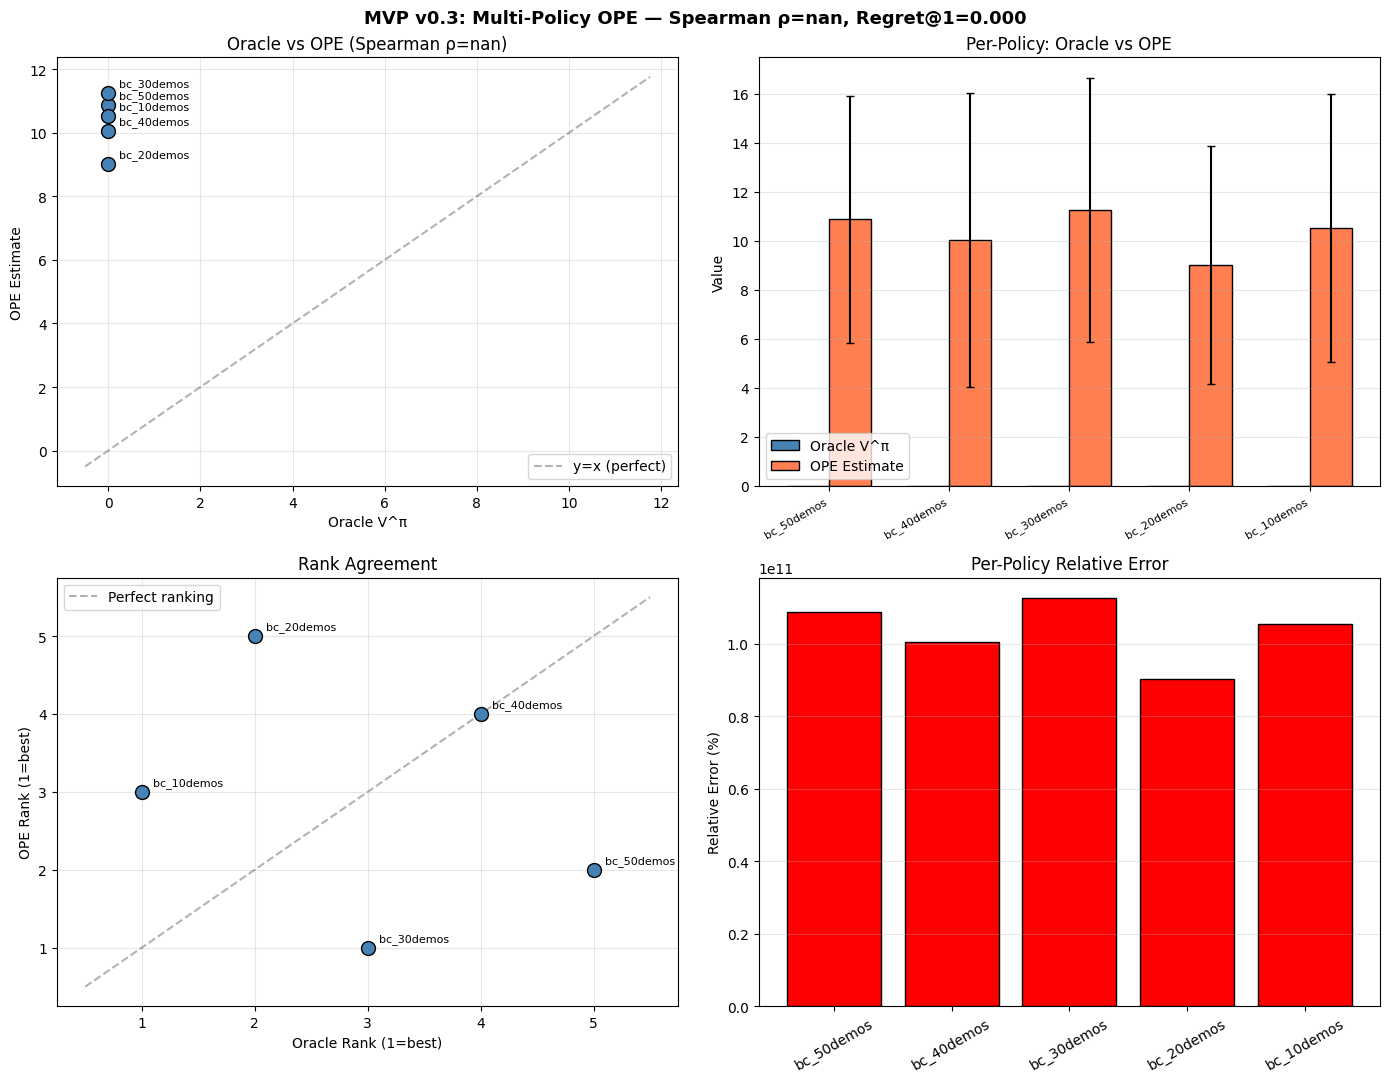

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# ── Panel 1: Oracle vs OPE scatter plot ──
ax = axes[0, 0]
ax.scatter(oracle_values, ope_estimates, s=100, c="steelblue", edgecolors="black", zorder=5)
for i, name in enumerate(POLICY_NAMES):
    ax.annotate(name, (oracle_values[i], ope_estimates[i]),
                textcoords="offset points", xytext=(8, 5), fontsize=8)
# Perfect correlation line
lims = [min(min(oracle_values), min(ope_estimates)) - 0.5,
        max(max(oracle_values), max(ope_estimates)) + 0.5]
ax.plot(lims, lims, "k--", alpha=0.3, label="y=x (perfect)")
ax.set_xlabel("Oracle V^π")
ax.set_ylabel("OPE Estimate")
ax.set_title(f"Oracle vs OPE (Spearman ρ={mp_result.spearman_rho:.3f})")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Panel 2: Bar chart comparing oracle and OPE per policy ──
ax = axes[0, 1]
x_pos = np.arange(len(POLICY_NAMES))
width = 0.35
bars1 = ax.bar(x_pos - width/2, oracle_values, width, label="Oracle V^π",
               color="steelblue", edgecolor="black")
bars2 = ax.bar(x_pos + width/2, ope_estimates, width, label="OPE Estimate",
               color="coral", edgecolor="black")
# Error bars on OPE
ope_stds = [ope_results[n]["std"] for n in POLICY_NAMES]
ax.errorbar(x_pos + width/2, ope_estimates, yerr=ope_stds,
            fmt="none", color="black", capsize=3)
ax.set_xticks(x_pos)
ax.set_xticklabels(POLICY_NAMES, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Value")
ax.set_title("Per-Policy: Oracle vs OPE")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# ── Panel 3: Ranking comparison ──
ax = axes[1, 0]
oracle_ranks = np.argsort(np.argsort(oracle_values)[::-1]) + 1
ope_ranks = np.argsort(np.argsort(ope_estimates)[::-1]) + 1
ax.scatter(oracle_ranks, ope_ranks, s=100, c="steelblue", edgecolors="black", zorder=5)
for i, name in enumerate(POLICY_NAMES):
    ax.annotate(name, (oracle_ranks[i], ope_ranks[i]),
                textcoords="offset points", xytext=(8, 5), fontsize=8)
ax.plot([0.5, len(POLICY_NAMES)+0.5], [0.5, len(POLICY_NAMES)+0.5],
        "k--", alpha=0.3, label="Perfect ranking")
ax.set_xlabel("Oracle Rank (1=best)")
ax.set_ylabel("OPE Rank (1=best)")
ax.set_title("Rank Agreement")
ax.set_xticks(range(1, len(POLICY_NAMES)+1))
ax.set_yticks(range(1, len(POLICY_NAMES)+1))
ax.legend()
ax.grid(True, alpha=0.3)

# ── Panel 4: Relative error per policy ──
ax = axes[1, 1]
rel_errors = [mp_result.per_policy[i].relative_error * 100 for i in range(len(POLICY_NAMES))]
colors = ["green" if e < 50 else "orange" if e < 100 else "red" for e in rel_errors]
ax.bar(POLICY_NAMES, rel_errors, color=colors, edgecolor="black")
ax.set_ylabel("Relative Error (%)")
ax.set_title("Per-Policy Relative Error")
ax.tick_params(axis="x", rotation=30)
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(f"MVP v0.3: Multi-Policy OPE — Spearman ρ={mp_result.spearman_rho:.3f}, "
             f"Regret@1={mp_result.regret_at_1:.3f}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

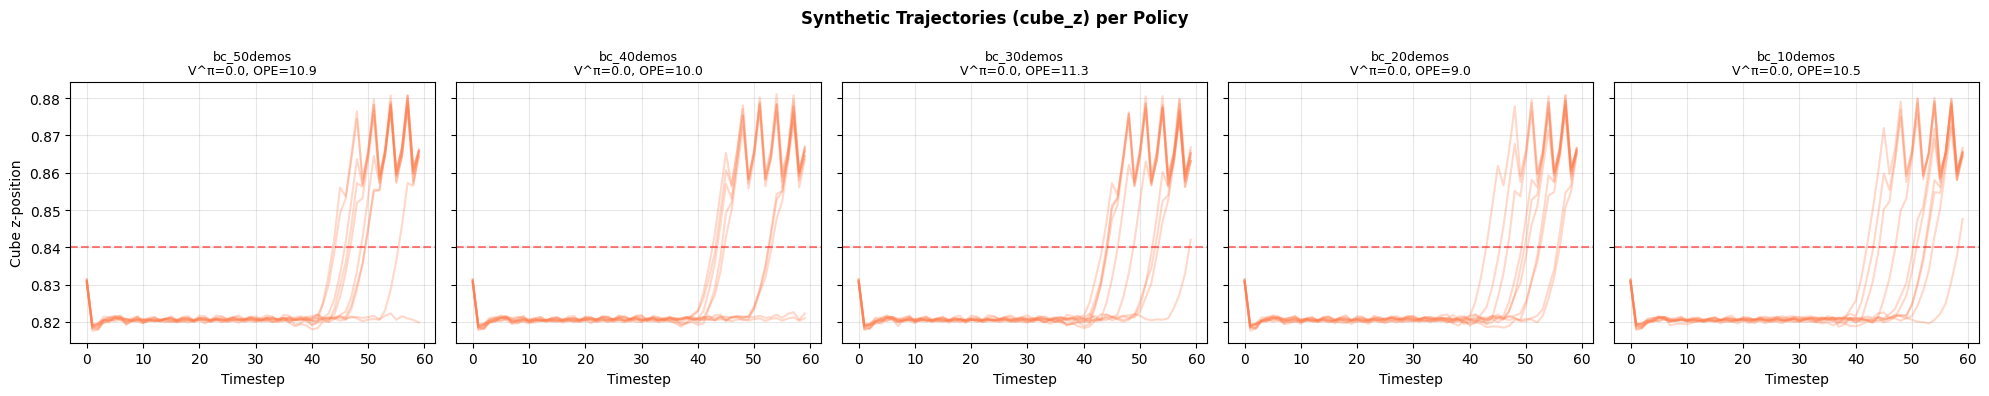

In [13]:
# ── Per-policy trajectory visualization: cube_z for each policy ──
fig, axes = plt.subplots(1, len(POLICY_NAMES), figsize=(4 * len(POLICY_NAMES), 4), sharey=True)

for idx, name in enumerate(POLICY_NAMES):
    ax = axes[idx]
    trajs = ope_results[name]["trajectories"]
    for j in range(min(10, NUM_SYNTHETIC_TRAJS)):
        ax.plot(trajs[j, :, CUBE_Z_INDEX], alpha=0.3, color="coral")
    ax.axhline(y=LIFT_THRESHOLD, color="red", linestyle="--", alpha=0.5)
    oracle_v = oracle_results[name]["mean"]
    ope_v = ope_results[name]["estimate"]
    ax.set_title(f"{name}\nV^π={oracle_v:.1f}, OPE={ope_v:.1f}", fontsize=9)
    ax.set_xlabel("Timestep")
    if idx == 0:
        ax.set_ylabel("Cube z-position")
    ax.grid(True, alpha=0.3)

plt.suptitle("Synthetic Trajectories (cube_z) per Policy", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary

Print final summary of all results.

In [14]:
print("=" * 70)
print("MVP v0.3: MULTI-TARGET-POLICY OPE — FINAL SUMMARY")
print("=" * 70)

print(f"\nSetup:")
print(f"  Data partition: {N_BEHAVIOR_DEMOS} behavior demos / {N_TARGET_DEMOS} target demos")
print(f"  Diffusion model: trained on behavior split ({DIFF_TRAIN_EPOCHS} epochs, "
      f"{DIFF_TRAIN_EPOCHS * DIFF_TRAIN_STEPS_PER_EPOCH:,} steps)")
print(f"  Diffusion final loss: {loss_history[-1]:.6f}")
print(f"  Target policies: {len(POLICY_NAMES)} BC_Gaussians on held-out demos {TARGET_DEMO_COUNTS}")
print(f"  Guidance scale: {GUIDANCE_SCALE}")
print(f"  Oracle rollouts per policy: {N_ORACLE_ROLLOUTS}")
print(f"  Synthetic trajectories per policy: {NUM_SYNTHETIC_TRAJS}")

print(f"\nPer-Policy Results:")
print(f"  {'Policy':<15} {'Demos':>6} {'Oracle':>8} {'OPE':>8} {'RelErr':>8} {'Success(O)':>10} {'Success(S)':>10}")
print(f"  {'-'*67}")
for i, (name, n_demos) in enumerate(zip(POLICY_NAMES, TARGET_DEMO_COUNTS)):
    o = oracle_results[name]
    e = ope_results[name]
    pp = mp_result.per_policy[i]
    print(f"  {name:<15} {n_demos:>5}  {o['mean']:>8.2f} {e['estimate']:>8.2f} "
          f"{pp.relative_error:>7.1%} {o['success_rate']*100:>9.1f}% {e['success_rate']*100:>9.1f}%")

print(f"\nRanking Metrics:")
print(f"  Spearman ρ = {mp_result.spearman_rho:.4f} (p = {mp_result.spearman_pvalue:.4f})")
print(f"  Regret@1   = {mp_result.regret_at_1:.4f}")
for k, reg in mp_result.regret_at_k.items():
    if k > 1:
        print(f"  Regret@{k}   = {reg:.4f}")

print(f"\nAggregate:")
print(f"  Mean MSE            = {mp_result.mean_mse:.4f}")
print(f"  Mean Relative Error = {mp_result.mean_relative_error:.2%}")

print(f"\n{'='*70}")
print("MVP v0.3 COMPLETE")
print("=" * 70)

MVP v0.3: MULTI-TARGET-POLICY OPE — FINAL SUMMARY

Setup:
  Data partition: 150 behavior demos / 50 target demos
  Diffusion model: trained on behavior split (10 epochs, 10,000 steps)
  Diffusion final loss: nan
  Target policies: 5 BC_Gaussians on held-out demos [50, 40, 30, 20, 10]
  Guidance scale: 0.1
  Oracle rollouts per policy: 20
  Synthetic trajectories per policy: 50

Per-Policy Results:
  Policy           Demos   Oracle      OPE   RelErr Success(O) Success(S)
  -------------------------------------------------------------------
  bc_50demos         50      0.00    10.88 108800000000.0%       0.0%      92.0%
  bc_40demos         40      0.00    10.04 100400000000.0%       0.0%      82.0%
  bc_30demos         30      0.00    11.26 112600000000.0%       0.0%      92.0%
  bc_20demos         20      0.00     9.02 90200000000.0%       0.0%      96.0%
  bc_10demos         10      0.00    10.54 105400000000.0%       0.0%      96.0%

Ranking Metrics:
  Spearman ρ = nan (p = nan)
  Re